# Multi-branch MLP regressor - intermediate integration

This notebook implements a multi-branch MLP regressor using the intermediate integration approach. In this approach, each input modality is processed through its own branch of the network, and the outputs of these branches are concatenated and passed through additional layers to produce the final output.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import pyarrow
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [54]:
project_root = Path.cwd().parent
print(project_root)

c:\Users\joddy\repos\multiomics_integration_publication


## Data processing

In [55]:
# import pre-processed data
lcms_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' / 'lcms_data_modelling.feather')
miRNA_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' /  'mirna_data_modelling.feather')
olink_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' / 'olink_data_modelling.feather')
scRNA_data = pd.read_feather(project_root / '00_data' / 'late_integration_data' /  'scRNA_modelling_data.feather')
combined_metadata = pd.read_feather(project_root / '00_data' / 'raw' / 'processed' / 'combined_metadata.feather')
nk_cell_proportions = pd.read_csv(project_root / '00_data' / 'nk_cell_proportions_run_4.csv')

In [56]:
# Extract vessel and day numbers
nk_cell_proportions[['vessel', 'day']] = nk_cell_proportions['vessel_day'].str.extract(r'V(\d+)_D(\d+)')
nk_cell_proportions['vessel'] = pd.to_numeric(nk_cell_proportions['vessel'])
nk_cell_proportions['day'] = pd.to_numeric(nk_cell_proportions['day'])
nk_cell_proportions['label'] = 'r4_v' + nk_cell_proportions['vessel'].astype(str) + '_d' + nk_cell_proportions['day'].astype(str)

In [57]:
# Set index to 'label' and drop the column for all modalities
miRNA_data.index = miRNA_data['label']
miRNA_data = miRNA_data.drop(columns=['label'])

olink_data.index = olink_data['label']
olink_data = olink_data.drop(columns=['label'])

scRNA_data.index = scRNA_data['label']
scRNA_data = scRNA_data.drop(columns=['label'])

lcms_data.index = lcms_data['label']
lcms_data = lcms_data.drop(columns=['label'])

target_variable = nk_cell_proportions[['proportion_NK', 'label']]
target_variable.index = target_variable['label']
target_variable = target_variable.drop(columns=['label'])

# Sort all omics data by their index in alphanumeric order
scRNA_data = scRNA_data.sort_index()
olink_data = olink_data.sort_index()
miRNA_data = miRNA_data.sort_index()
lcms_data = lcms_data.sort_index()
target_variable = target_variable.sort_index()

# check that the indexes match up
print(olink_data.index.equals(target_variable.index))
print(scRNA_data.index.equals(target_variable.index))
print(miRNA_data.index.equals(target_variable.index))
print(lcms_data.index.equals(target_variable.index))

False
True
False
False


## Multi-branch MLP regressor

In [58]:
modalities = [miRNA_data, olink_data, scRNA_data, lcms_data]
target = target_variable['proportion_NK']

# Align sample IDs across all modalities and target (union of all sample IDs)
all_ids = sorted(set().union(*[df.index for df in modalities], target.index))
modality_matrices, modality_masks = [], []

for df in modalities:
    df_aligned = df.reindex(all_ids).fillna(0.0)
    mask = (~df.reindex(all_ids).isna()).astype(float).values
    modality_matrices.append(torch.tensor(df_aligned.values, dtype=torch.float32))
    modality_masks.append(torch.tensor(mask, dtype=torch.float32))

target_aligned = target.reindex(all_ids).values.astype(np.float32)
target_tensor = torch.tensor(target_aligned, dtype=torch.float32)

In [59]:
class MaskedBranch(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        # Input dimension doubles because we append the mask
        self.net = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x, mask):
        # Concatenate feature values and mask
        x_masked = torch.cat([x, mask], dim=1)
        return self.net(x_masked)

class MultiBranchMLP(nn.Module):
    def __init__(self, input_dims, hidden_dim=64, final_hidden=64):
        super().__init__()
        self.branches = nn.ModuleList([MaskedBranch(d, hidden_dim) for d in input_dims])
        self.fc = nn.Sequential(
            nn.Linear(len(input_dims) * hidden_dim, final_hidden),
            nn.ReLU(),
            nn.Linear(final_hidden, 1)
        )

    def forward(self, Xs, Masks):
        branch_outs = [branch(x, m) for branch, x, m in zip(self.branches, Xs, Masks)]
        combined = torch.cat(branch_outs, dim=1)
        return self.fc(combined).squeeze(1)

In [60]:
def train_one_fold(model, optimizer, criterion, train_idx, val_idx, num_epochs=100, device='cpu'):
    Xs_train = [X[train_idx].to(device) for X in modality_matrices]
    Ms_train = [M[train_idx].to(device) for M in modality_masks]
    y_train = target_tensor[train_idx].to(device)

    Xs_val = [X[val_idx].to(device) for X in modality_matrices]
    Ms_val = [M[val_idx].to(device) for M in modality_masks]
    y_val = target_tensor[val_idx].to(device)

    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(Xs_train, Ms_train)
        loss = criterion(y_pred_train, y_train)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_val = model(Xs_val, Ms_val).cpu().numpy()
        y_true_val = y_val.cpu().numpy()

    r2 = r2_score(y_true_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
    
    # <--- Return the predictions as well
    return r2, rmse, y_true_val, y_pred_val

In [61]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores, rmse_scores = [], []
all_y_true, all_y_pred = [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_ids)):
    model = MultiBranchMLP([m.shape[1] for m in modality_matrices])
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    r2, rmse, y_true, y_pred = train_one_fold(model, optimizer, criterion, train_idx, val_idx, num_epochs=100, device=device)
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    all_y_true.append(y_true)
    all_y_pred.append(y_pred)

    print(f"Fold {fold+1}: R²={r2:.3f}, RMSE={rmse:.3f}")

print(f"\nAverage R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Average RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")

Fold 1: R²=0.982, RMSE=0.032
Fold 2: R²=0.985, RMSE=0.040
Fold 3: R²=0.959, RMSE=0.044
Fold 4: R²=0.922, RMSE=0.092
Fold 5: R²=0.958, RMSE=0.032

Average R²: 0.961 ± 0.022
Average RMSE: 0.048 ± 0.022


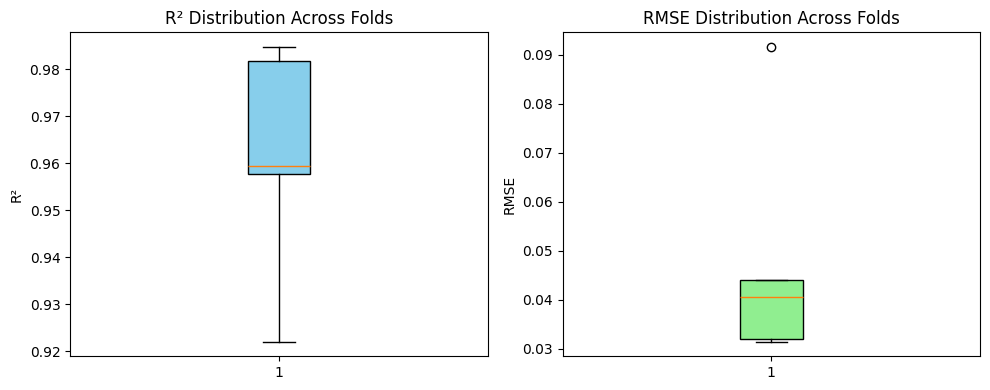

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(r2_scores, vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
axes[0].set_title("R² Distribution Across Folds")
axes[0].set_ylabel("R²")

axes[1].boxplot(rmse_scores, vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title("RMSE Distribution Across Folds")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

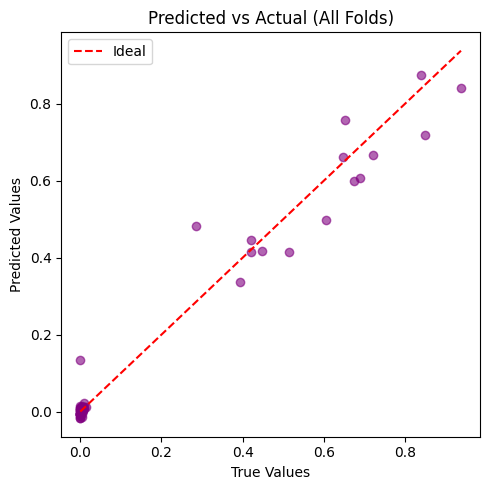

In [63]:
all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)

plt.figure(figsize=(5,5))
plt.scatter(all_y_true, all_y_pred, alpha=0.6, color='purple')
plt.plot([all_y_true.min(), all_y_true.max()], [all_y_true.min(), all_y_true.max()], 'r--', label='Ideal')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (All Folds)")
plt.legend()
plt.tight_layout()
plt.show()